## Detección de outliers

Basado en: https://medium.com/subex-ai-labs/an-introduction-to-outlier-detection-methods-using-python-f2013824a7b7

Abrir el link anterior para ver un poco los posibles tipos de outliers según la forma de identificarlos.


Empezamos por cargar los datos, los cuales corresponden al peso, sexo y estatura de un conjunto de personas.



In [1]:
import pandas as pd
import numpy as np 

df = pd.read_csv("weight-height.csv")



In [2]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


Para este ejemplo, dejaremos solo los datos correspondientes a hombres.

In [3]:
df = df[df['Gender']=='Male'][['Height', 'Weight']]
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
4995,68.860062,177.131052
4996,68.973423,159.285228
4997,67.013795,199.195400
4998,71.557718,185.905909


¿Qué outliers (datos atípicos) se alcanzan a observar en la primera vista de los datos?

In [4]:
df.shape

(5000, 2)

In [5]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


Antes de continuar, llevemos estos datos a valores que entendamos más fácilmente: cm y kg.

In [6]:
df['Height'] = df['Height']*2.54
df

,Height,Weight
0,187.571423,241.893563
1,174.706036,162.310473
2,188.239668,212.740856
3,182.196685,220.042470
4,177.499761,206.349801
...,...,...
4995,174.904559,177.131052
4996,175.192494,159.285228
4997,170.215039,199.195400
4998,181.756605,185.905909


In [7]:
df['Weight'] = df['Weight']*0.453592
df

,Height,Weight
0,187.571423,109.720985
1,174.706036,73.622732
2,188.239668,96.497550
3,182.196685,99.809504
4,177.499761,93.598619
...,...,...
4995,174.904559,80.345228
4996,175.192494,72.250505
4997,170.215039,90.353440
4998,181.756605,84.325433


Ahora si tenemos datos que logramos entender. Hagamos primero un describe para ver la info.


In [8]:
df.describe()

,Height,Weight
count,5000.000000,5000.000000
mean,175.326919,84.831057
std,7.272940,8.972573
min,148.353539,51.211870
25%,170.623685,78.874100
50%,175.330380,84.836920
75%,180.311409,90.880696
max,200.656806,122.465167


Claramente vemos algunos pesos muy altos y muy bajos, al igual que estaturas. Sabemos por ende que hay potenciales outliers en nuestro dataset.

Esto se puede confirmar también al graficar los datos:

<AxesSubplot:xlabel='Height', ylabel='Weight'>

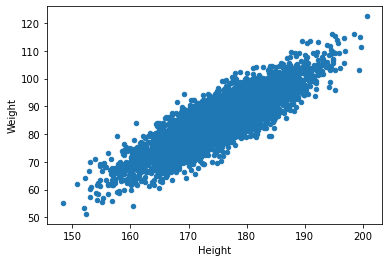

In [9]:
df.plot.scatter('Height', 'Weight')

Antes de continuar, para fines del ejemplo, creemos un segundo dataset "contaminado". En este dataset añadiremos algunos valores que sabemos que son outliers.

In [10]:
outliers_nuevos = [
[220, 190],
[210, 180],
[110, 180],
[20, 10],
[130, 30],
[185, 60],
[160, 100]
]

In [11]:
df_cont = pd.concat([df,pd.DataFrame(outliers_nuevos, columns=['Height', 'Weight'])]).reset_index(drop=True)
df_cont

,Height,Weight
0,187.571423,109.720985
1,174.706036,73.622732
2,188.239668,96.497550
3,182.196685,99.809504
4,177.499761,93.598619
...,...,...
5002,110.000000,180.000000
5003,20.000000,10.000000
5004,130.000000,30.000000
5005,185.000000,60.000000


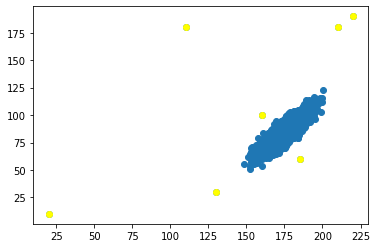

In [12]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(x=df_cont['Height'], y=df_cont['Weight'])
plt.scatter(x=df_cont['Height'][-len(outliers_nuevos):], y=df_cont['Weight'][-len(outliers_nuevos):], c='yellow')


# Métodos de detección de outliers

Hay una gran variedad de formas de identificar outliers en un conjunto de datos. Aquí vamos a analizar algunas de ellas.


## Métodos univariados de detección de outliers

Primero, empecemos por ver unos métodos que miran cada variable de forma independiente para detectar outliers. Estos son los métodos de detección de outliers univariados.


### 1. Usando la lógica (conocimiento de negocio) en cada variable

Esta suele ser la primera forma de identificar datos atípicos: simplemente con lo que nos dice nuestra lógica humana, o con el conocimiento que tenemos del problema.

En este caso, nosotros ya sabemos más o menos cuales son rangos habituales donde se puede encontrar el peso y la estatura de una persona.

Asumamos que marcaremos como outlier todas las personas cuyo peso sea mayor a 110kg o menor a 55kg, y cuya altura sea mayor a 195cm o menor a 155cm.

(0.0, 230.0)

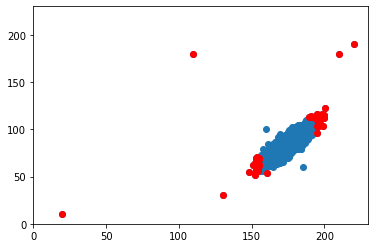

In [13]:
## Con datos contaminados
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(x=df_cont['Height'], y=df_cont['Weight'])

df_cont_outl = df_cont[(df_cont['Height']>195) | (df_cont['Height']<155) | (df_cont['Weight']>110) | (df_cont['Weight']<55)]

plt.scatter(x=df_cont_outl['Height'], y=df_cont_outl['Weight'], c='red')

# Fijar los ejes para ver mejor las formas de las regiones de rechazo
plt.xlim(0, 230) 
plt.ylim(0, 230)

De esta forma, estoy logrando marcar varios (pero no todos) de los outliers añadidos, y también veo que la distribución original en los extremos se marca como outlier.

### 2. Usando un boxplot

Debido a que no siempre se puede saber de antemano desde que valor considerar algo como outlier, es común utilizar ténicas estadísticas para hallar estos outliers. La más común sería el boxplot.

Aquellos valores que queden por fuera de los bigotes son los que serán marcados como outliers.

<AxesSubplot:>

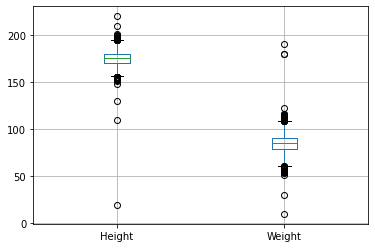

In [14]:
df_cont.boxplot()

En este caso, los bigotes de la altura parecen estar máximo en 190cm y minimo en 160cm y en peso máximo 110kg y mínimo 60kg. Aquí para fines didácitos se miran a ojo, pero en un proyecto hay que hallar el valor exacto de donde están los bigotes.

Los outliers marcados serían los siguientes:

(0.0, 230.0)

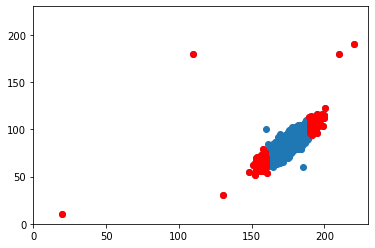

In [15]:
## Con datos contaminados
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(x=df_cont['Height'], y=df_cont['Weight'])

df_cont_outl = df_cont[(df_cont['Height']>190) | (df_cont['Height']<160) | (df_cont['Weight']>110) | (df_cont['Weight']<60)]

plt.scatter(x=df_cont_outl['Height'], y=df_cont_outl['Weight'], c='red')


# Fijar los ejes para ver mejor las formas de las regiones de rechazo
plt.xlim(0, 230) 
plt.ylim(0, 230)

El comportamiento es similar al anterior, aunque aun no marca como outliers dos que le agregamos.

### 3. Usando z score

Ahora usemos la fórmula que conocemos de la estadística para hallar outliers según la distribución normal (Notese que estos datos originales se distribuyen de forma gaussiana).

Lo que hacemos es calcular los Z-score de cada individuo en cada columna, y quienes tengan valor absoluto muy grande, son outliers (recuerden en estadística que calculaban el valor Z y lo buscaban en la tabla de la normal).

https://www.google.com/search?client=firefox-b-d&q=z+scores

In [16]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

df_z = pd.DataFrame(ss.fit_transform(X=df_cont), columns = df.columns)
df_z

,Height,Weight
0,1.591094,2.648563
1,-0.075453,-1.197510
2,1.677656,1.239678
3,0.894865,1.592549
4,0.286439,0.930813
...,...,...
5002,-8.457291,10.136410
5003,-20.115639,-7.976166
5004,-5.866547,-5.845275
5005,1.257999,-2.648938


(0.0, 230.0)

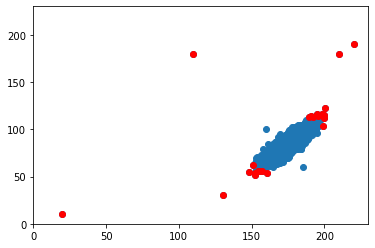

In [17]:
### Graficar los outliers
# Se suele considerar que un z-score mayor a 3 representa outliers

plt.figure()
plt.scatter(x=df_cont['Height'], y=df_cont['Weight'])

df_cont_outl = df_cont[(df_z['Height']>3) | (df_z['Height']<-3) | (df_z['Weight']>3) | (df_z['Weight']<-3)]

plt.scatter(x=df_cont_outl['Height'], y=df_cont_outl['Weight'], c='red')


# Fijar los ejes para ver mejor las formas de las regiones de rechazo
plt.xlim(0, 230) 
plt.ylim(0, 230)

Sigue teniendo los mismos problemas que los anteriores: no logra detectar 2 de los outliers que agregue, mientras que si marca como outliers varios que no agregue.

## Métodos multivariados de detección de outliers

Los tres métodos vistos anteriormente miraban una sola variable a la vez para detectar posibles outliers. Sin embargo, hemos notado que a veces ver una variable a la vez no es suficiente. Por ejemplo, encontrar en la tabla un peso de 50kg, o encontrar una estatura de 1.85m, pues de por si puede no ser raro; pero si nos damos cuenta que ambos pertenecen a la misma persona (registro), ya esto si se torna raro. 

Además, mirar una variable a la vez (como en los casos anteriores) conllevaba a crear regiones de aceptación rectangulares, pero claramente los datos no tienen esa forma (y en la mayoría de los casos no los tendrán ya que suele ser común ver datos con formas gaussianas).

Por ende, resulta necesario mirar métodos que analicen todas las variables al mismo tiempo para intentar determinar si un dato particular es o no un outlier.

Así, estos métodos multivariados nos permiten buscar outliers de forma multivariada, permitiendo así que toda una fila se marque como outlier (aquí buscamos filas outliers, en los anteriores buscábamos celdas outliers). Esto les da mayor utilidad sobre los demás métodos (es común querer buscar registros outliers y no solo celdas outliers).



### 4. Usando la distancia euclideana al centroide

Usualmente, los humanos pensamos en la distancia euclidiana cuando queremos calcular distancias en un plano. Esta distancia está basada en darle el mismo peso a los cambios de valor en cualquiera de las dimensiones.

Recordar que la distancia euclidiana entre un par de puntos "p" y "q" N-dimensionales está dada por la siguiente fórmula:

$$
   d\left( p,q\right)   = \sqrt {\sum _{i=1}^{n}  \left( q_{i}-p_{i}\right)^2 } 
$$

En 2 dimensiones dicha fórmula se reduce a la fórmula de la distancia entre dos puntos en el plano cartesiano:  https://www.neurochispas.com/matematicas/distancia-entre-dos-puntos-formula-y-ejemplos/. Sin embargo, la fórmula de arriba es más general porque funciona para n-dimensiones (no solo para 2).

Podríamos entonces calcular primero el centro de todos los puntos (centroide), que sería la media de cada una de las dimensiones. Posteriormente, calcularemos las distancias euclidianas de cada uno de estos puntos al centroide, y seleccionaremos como outliers todos los puntos que tengan una distancia euclidiana al centro superior a un umbral.

Note entonces que aquí se formaría una "bola" (https://es.wikipedia.org/wiki/Bola_(matem%C3%A1tica)) con centro en el centroide (un círculo para nuestro caso), y los puntos que queden por fuera de este círculo serían los outliers.

In [18]:
# Centroide de todos los puntos
centroid = np.mean(df_cont).values
centroid

# Calculo la distancia euclideana de cada punto al centroide
distancias_euc = []
for pos in range(len(df_cont)):
    
    # Valores que corresponden a este punto
    valores_punto = df_cont.loc[pos].values

    # Fórmula para calcular la distancia euclidiana de este punto al centroide
    dist_euc = np.sqrt(np.sum((valores_punto - centroid)**2)) 
    
    # Almacenar la distancia
    distancias_euc.append(dist_euc)



Ahora, marco como outlier todo lo que tenga una distancia euclidiana al centroide superior a un umbral note que aquí es importante definir bien el umbral, para este caso usaremos como umbral un percentil de las distancias

Para este ejemplo, quiero que me marque como datos inliers el 95% de mis puntos, y como datos outliers el 5% de los puntos. Así, el 5% de los puntos más alejados en distancia euclidiana al centro serán mis outliers.


In [19]:
# Porcentaje outliers
porcentaje_outliers = 5

# Hallar el umbral correspondiente
umbral_rechazo = np.percentile(distancias_euc, q = 100 - porcentaje_outliers)

# Marcar todos los índices de los puntos que superen este umbral (y por ende sean outliers)
indices_outliers = np.where(distancias_euc > umbral_rechazo)

In [20]:
# Los puntos outliers serían entonces estos 
df_cont.loc[indices_outliers]

,Height,Weight
0,187.571423,109.720985
23,191.023173,103.764514
82,187.518363,107.917128
123,159.275754,68.025019
157,157.320801,66.797630
...,...,...
5001,210.000000,180.000000
5002,110.000000,180.000000
5003,20.000000,10.000000
5004,130.000000,30.000000


Por último, procedo a graficar entonces los outliers.

(0.0, 230.0)

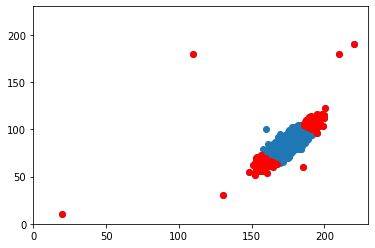

In [21]:
### Graficar los outliers

plt.figure()
plt.scatter(x=df_cont['Height'], y=df_cont['Weight'])

df_cont_outl = df_cont.iloc[indices_outliers]


plt.scatter(x=df_cont_outl['Height'], y=df_cont_outl['Weight'], c='red')


# Fijar los ejes para ver mejor las formas de las regiones de rechazo
plt.xlim(0, 230) 
plt.ylim(0, 230)

Note que este método ya presenta una forma y comportamiento diferente a los anteriores. Ya se logran capturar casi todos los outliers agregados, sin embargo, sigue habiendo uno que no se capturó. 

Y además esta método está trazando un círculo alrededor del centroide para marcar su región de rechazo (lo que queda fuera del círculo, sería lo que se marca como outlier).

Sin embargo, nuestros datos no tenían forma circular: su verdadera forma era una elipse, por lo que aún no tenemos el rendimiento esperado. Por ende, vamos al siguiente método, el cual resolverá este problema de la forma.



### 5. Usando distancia de Mahalanobis (multivariado)

Basado en: https://towardsdatascience.com/multivariate-outlier-detection-in-python-e946cfc843b3

Usando la distancia de Mahalanobis podemos también hallar outliers. Lo que hace este método es intentar "pintar una elipse" para incluir aquí a la mayor parte de nuestros datos, y los datos que queden por fuera de esta elipse serán outliers.

Lo que hacemos es que calculamos la distancia de cada punto al centro de la distribución (al centro de la elipse). Los datos que tengan una distancia de Mahalanobis al centro que supere cierto umbral (que estén "por fuera de la elipse") serán outliers.  Notar que esto también funciona de forma análoga para conjuntos de datos con 3 o más dimensiones.


In [22]:
from scipy.stats import chi2

# Aquí se realizan todos los pasos para identificar outliers con la distancia de Mahalanobis

# Calcular matriz de covarianza y su inversa
covariance  = np.cov(df_cont.values , rowvar=False)
covariance_pm1 = np.linalg.matrix_power(covariance, -1)

# Centro de la distribución (centro de la elipse, que sería un vector con las medias de todas las columnas)
centerpoint = np.mean(df_cont, axis=0)

# Ahora, se calculan las distancias de Mahalanobis de cada punto al centro de la distribución (al centro de la elipse)
# Y se sabe que mientras más lejos estén del centro, más propensos son a ser outliers
distances = []
for i, val in enumerate(df_cont.values):
    p1 = val
    p2 = centerpoint
    distance = (p1-p2).T.dot(covariance_pm1).dot(p1-p2) # Notar que esta es la fórmula de las slides
    distances.append(distance)
distances = np.array(distances)

In [23]:

# OJO !
# El unico parametro que cambia el usuario es este valor para el umbral de corte de la chi-squared (p acumulada),
# En este ejemplo usamos 0.99. El valor máximo es 1. Usualmente se usa un valor entre 0.9 y 1.
# Este valor representa aproximadamente, según la distribución chi-squared, la proporción de datos que NO son outliers
# Valores más altos marcarán menos cosas como outliers ("dibujan una elipse más grande"); 
# mientras valores más bajos traerán más outliers ("dibujan una elipse más pequeña")
# Este valor influirá en la distancia "máxima" que puede tener un valor hasta el centro para que no sea un outlier
valor_corte = 0.99
cutoff = chi2.ppf(valor_corte, df_cont.shape[1])

# Por ultimo, los outliers son aquellos valores que quedan ´por fuera del umbral (es decir, por fuera de la elipse
outlierIndexes = np.where(distances > cutoff )

print('--- Indices de los Outliers ----')
print(outlierIndexes)

--- Indices de los Outliers ----
(array([ 565,  727,  994, 1243, 1317, 1506, 1610, 1750, 1942, 2014, 2070,
       2334, 2417, 2500, 2527, 2971, 3285, 3332, 3669, 3757, 4077, 4170,
       4331, 4637, 4794, 4980, 5000, 5001, 5002, 5003, 5004, 5005, 5006],
      dtype=int64),)


In [24]:
1 - len(outlierIndexes[0])/len(df_cont)  # Deberia ser aproximadamente similar al valor de corte establecido

0.9934092270820851

Ahora, imprimamos por ejemplo los outliers por mahalanobis


In [25]:
df_cont.loc[outlierIndexes]

,Height,Weight
565,156.855185,56.031377
727,161.037075,83.999858
994,198.363503,115.979317
1243,157.642143,79.410883
1317,199.293614,103.120769
1506,192.274490,113.200972
1610,194.608567,116.057558
1750,189.495857,113.373634
1942,152.353937,51.211870
2014,200.656806,122.465167


(0.0, 230.0)

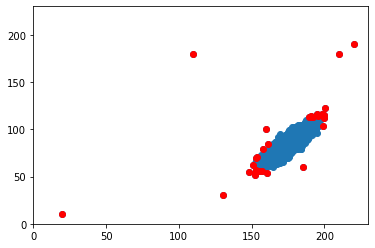

In [26]:
### Graficar los outliers

plt.figure()
plt.scatter(x=df_cont['Height'], y=df_cont['Weight'])

df_cont_outl = df_cont.iloc[outlierIndexes]

plt.scatter(x=df_cont_outl['Height'], y=df_cont_outl['Weight'], c='red')


# Fijar los ejes para ver mejor las formas de las regiones de rechazo
plt.xlim(0, 230) 
plt.ylim(0, 230)


Note que este método es el primero que si logra marcar como outliers todos los datos contaminados que fueron agregados. Y es el primero que logra formar una "elipse" muy clara para marcar datos como outliers o no. 

¡Por lo que para este caso este método si parece ser muy acertado!

__Nota__: para este caso, las distancias que estamos calculando asumimos que se deben distribuir siguiendo una chi-squared, lo que si parece en general pasar en este ejercicio ya que el peso y la estatura suelen distribuirse de forma normal, por lo que al calcular la distancia de Mahalanobis que es una suma de normales al cuadrado se vuelve chi-squared (que es algo que también se comprueba al ver la forma gaussiana elíptica de los datos originales). Esto implica que este método sea un método paramétrico (hace un supuesto de normalidad en los datos). Sin embargo, tenga en cuenta que si los datos no son normales (no tienen forma de elipse), no sería del todo apropiado usar este método.

Así, miremos por ejemplo un último método que no hace este tipo de supuestos.

### 6. Con un método de ML: DBSCAN clustering (multivariado)

DBSCAN es un método de clustering basado en densidad. Intentaré agrupar todo el dataset en un cluster, y de forma automática detectará cuales puntos no son suficientemente densos para pertenecer a él. https://es.wikipedia.org/wiki/DBSCAN

La ventaja es que funciona con clusters de varias formas y tamaños (no requiere que los datos tengan una forma específica).


In [27]:
# Import DBSCAN library
from sklearn.cluster import DBSCAN

# Convert Height column to array with shape (-1,1) 
data = df_cont.copy()

print(f"Shape of data : {data.shape}")
print(f"Type of data : {type(data)}")

# Create DBSCAN model with parameters
model = DBSCAN(eps=7.5,min_samples=2) #### Estos parametros son los que se tendrían que ajustar 
# (radio de cada anillo y número mínimo de muestras en el anillo para que sean válidos)

# Fit model to data
model.fit(data)

# Printing total number of outliers
print(f"Total number of outliers : {sum(model.labels_ == -1)}")

# Outliers 
outliers = df_cont[model.labels_ == -1]


Shape of data : (5007, 2)
Type of data : <class 'pandas.core.frame.DataFrame'>
Total number of outliers : 7


(0.0, 230.0)

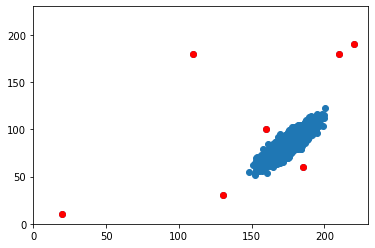

In [28]:
### Graficar los outliers

plt.figure()
plt.scatter(x=df_cont['Height'], y=df_cont['Weight'])

df_cont_outl = df_cont.iloc[model.labels_ == -1]

plt.scatter(x=df_cont_outl['Height'], y=df_cont_outl['Weight'], c='red')


# Fijar los ejes para ver mejor las formas de las regiones de rechazo
plt.xlim(0, 230) 
plt.ylim(0, 230)


En este caso se hace una distinción perfecta de los datos que se le agregaron como contaminados y los datos originales, pero se debe tener en cuenta que el rendimiento del modelo dependerá de los hiperparámetros min_samples y eps.

## Conclusión

Luego de aplicar varias técnicas de detección de outliers, se busca llegar a un consenso entre estas para identificar los outliers en un conjunto de datos. Este paso es imprescindible en cualquier proyecto de analítica.

Una vez detectados los outliers, se debe decidir si se desea conservalos (lo cual puede ser una opción dependiendo de su 
naturaleza), o ver qué tratamiento aplicar sobre ellos.

Tal como se menciona en https://www.aprendemachinelearning.com/deteccion-de-outliers-en-python-anomalia/, los outliers pueden significar varias cosas:

- ERROR: Si tenemos un grupo de “edades de personas” y tenemos una persona con 160 años, seguramente sea un error de carga de datos. En este caso, la detección de outliers nos ayuda a detectar errores, y es necesario removerlo o corregirlo.

- LIMITES: En otros casos, podemos tener valores que se escapan del “grupo medio”, pero queremos mantener el dato original o corregirlo, pero no se debe remover porque podría afectar el rendimiento de los modelos en estos escenarios. (Pensar en una persona de 100 años, es algo raro pero que si puede pasar y quizás sea bueno incluirlo en el informe).

- Punto de Interés: puede que sean los casos “anómalos” los que queremos detectar y que sean nuestro objetivo (y no nuestro enemigo!). En estos casos a veces no es necesario aplicarles ningún tratamiento. (Pensar por ejemplo en un modelo diseñado para predecir si en un día particular habrá o no un gran terremoto; los días donde si hay terremoto son muy pocos y escasos y son "outliers", pero no puedo removerlos ya que son los de mayor interés).

#### Nota: Al final, si  se decide que se debe aplicar algún tratamiento a los outliers (y no dejarlos intactos), usualmente se suele aplicar remoción, imputación (tratarlos como si fueran missing e imputarlos) o truncamiento para estos valores.


### Ejercicio opcional

1. Use tres de los métodos de detección de outliers aquí presentados para detectar datos atípicos en el conjunto de las mujeres de los datos aquí usados (al menos uno unidimensional y uno multidimensional).

2. Grafique los outliers obtenidos por cada método junto con el conjunto de datos.

3. Analice los outliers marcados por cada uno de los métodos. Según su opinión, ¿cuál da un mejor resultado al momento de detectar datos atípicos?

4. Decida si debe realizar algún tratamiento adicional para los datos atípicos y aplíquelo en caso de que se requiera.